# Predicción de la Firma en Álgebra Lineal a partir del rendimiento en asignaturas relacionadas

Este notebook parte de los datos de rendimiento académico ya cargados y filtrados (celdas originales del parcial) y agrega, a continuación, el pipeline de **regresión lineal** solicitado: preparación del dataset, partición estratificada, dos modelos de regresión (simple y múltiple con **BGD**/**SGD**), y la evaluación comparativa entre ambos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Configuración
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("="*80)
print("📊 PREDICCIÓN DE APROBACIÓN - ALGEBRA LINEAL")
print("🤖 REGRESIÓN LOGÍSTICA")
print("="*80)

# =============================================================================
# 1. CARGAR DATOS
# =============================================================================
print("\n📂 Cargando datos concatenados...")
try:
    df =pd.read_csv(r'datos_concatenados.csv')

    print(f"✅ Datos cargados: {len(df):,} registros")
except FileNotFoundError:
    print("❌ No se encontró el archivo 'datosConcatenados.csv'")
    exit()


📊 PREDICCIÓN DE APROBACIÓN - ALGEBRA LINEAL
🤖 REGRESIÓN LOGÍSTICA

📂 Cargando datos concatenados...
✅ Datos cargados: 72,740 registros


In [2]:
# =============================================================================
# 2. FILTRAR
# =============================================================================
print("\n🔍 Filtrando Algebra Lineal...")
mask = df['Asignatura'].str.upper().str.contains('ALGEBRA LINEAL', na=False)
df_algebra_lineal = df[mask].copy()
print(f"✅ Registros de Algebra Lineal: {len(df_algebra_lineal):,}")
print(f"   Estudiantes únicos: {df_algebra_lineal['ALUMNO_ID'].nunique():,}")



🔍 Filtrando Algebra Lineal...
✅ Registros de Algebra Lineal: 1,980
   Estudiantes únicos: 1,664


In [3]:
print("\n🔍 Filtrando Algebra Moderna...")
mask = df['Asignatura'].str.upper().str.contains('ALGEBRA MODERNA', na=False)
df_algebra_moderna = df[mask].copy()
print(f"✅ Registros de Algebra Moderna: {len(df_algebra_moderna):,}")
print(f"   Estudiantes únicos: {df_algebra_moderna['ALUMNO_ID'].nunique():,}")



🔍 Filtrando Algebra Moderna...
✅ Registros de Algebra Moderna: 1,131
   Estudiantes únicos: 899


In [4]:
print("\n🔍 Filtrando Geometria Vectorial...")
mask = df['Asignatura'].str.upper().str.contains('GEOMETRIA VECTORIAL', na=False)
df_geometria_vectorial = df[mask].copy()
print(f"✅ Registros de Geometria Vectorial: {len(df_geometria_vectorial):,}")
print(f"   Estudiantes únicos: {df_geometria_vectorial['ALUMNO_ID'].nunique():,}")



🔍 Filtrando Geometria Vectorial...
✅ Registros de Geometria Vectorial: 1,187
   Estudiantes únicos: 935


In [5]:
mask_firma_AL=df_algebra_lineal['Firma']>50


In [6]:
df_anho_semestre = df_algebra_lineal.groupby(['Anho', 'Semestre']).agg({'ALUMNO_ID': 'nunique'}).reset_index()


In [7]:
df_anho_semestre.head(10)


   Anho  Semestre  ALUMNO_ID
0  2025         1       1220
1  2025         2        314
2  2026         1        444

In [8]:
np.sum(mask_firma_AL)


np.int64(526)

In [9]:
mask_firma_AL.value_counts()


Firma
False    1454
True      526
Name: count, dtype: int64

In [10]:
merge_aux=df_algebra_lineal.merge(df_algebra_moderna, on='ALUMNO_ID', how='inner')
nuevo=merge_aux.merge(df_geometria_vectorial, on='ALUMNO_ID', how='inner')


In [11]:
nuevo.head(10)


             ALUMNO_ID  Cod.Asign_x    Asignatura_x Cod.Car.Sec_x  \
0  FIUNA_ALUMNO_006371        23023  ALGEBRA LINEAL    MCT-PLS23    
1  FIUNA_ALUMNO_006797        23023  ALGEBRA LINEAL    MCT-PLS23    
2  FIUNA_ALUMNO_011263        23023  ALGEBRA LINEAL    ELE-PLS23    
3  FIUNA_ALUMNO_011263        23023  ALGEBRA LINEAL    ELE-PLS23    
4  FIUNA_ALUMNO_012732        23023  ALGEBRA LINEAL    ELE-PLS23    
5  FIUNA_ALUMNO_012732        23023  ALGEBRA LINEAL    ELE-PLS23    
6  FIUNA_ALUMNO_010887        23023  ALGEBRA LINEAL    CIV-PLS23    
7  FIUNA_ALUMNO_010887        23023  ALGEBRA LINEAL    CIV-PLS23    
8  FIUNA_ALUMNO_011574        23023  ALGEBRA LINEAL    CIV-PLS23    
9  FIUNA_ALUMNO_011574        23023  ALGEBRA LINEAL    CIV-PLS23    

   Cod.Curso_x  Convocatoria_x  Anho_x  Semestre_x  Doc.Firma_x Aprobado_x  \
0            2               1    2025           1            0          N   
1            2               1    2025           1            0          N   
2     

## 🎯 Definición del problema

A partir del DataFrame `nuevo` (resultado del cruce de las tres asignaturas por `ALUMNO_ID`):

| Columna en `nuevo` | Asignatura | Rol en el modelo |
|---|---|---|
| `Asignatura_x` / **`Firma_x`** | ALGEBRA LINEAL | **Target (Y)** a predecir |
| `Asignatura_y` / `Firma_y` | ALGEBRA MODERNA | Variable predictora — Modelo 1 y 2 |
| `Asignatura` / `Firma` | GEOMETRIA VECTORIAL | Variable predictora — Modelo 2 |

**Plan de trabajo:**
1. Preparar el dataset de modelado y aplicar una **partición estratificada 80/20** de `nuevo` en train/test.
2. **Modelo 1** — Regresión lineal simple: `Firma_y` (Algebra Moderna) → `Firma_x` (Algebra Lineal), con curva de predicción.
3. **Modelo 2** — Regresión lineal múltiple: `Firma_y` (Algebra Moderna) + `Firma` (Geometría Vectorial) → `Firma_x`, optimizada con **BGD** y **SGD** implementados desde cero, comparando ambos y graficando la superficie de predicción del mejor.
4. Comparación de **trayectorias de optimización** (BGD vs SGD).
5. **Evaluación comparativa de desempeño** entre el Modelo 1 y el Modelo 2.

### 1️⃣ Preparación del dataset de modelado

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (necesario para proyección 3D)

np.random.seed(42)
RANDOM_STATE = 42


In [13]:
# =============================================================================
# DATASET DE MODELADO: Firma_x (target), Firma_y (Algebra Moderna), Firma (Geom. Vectorial)
# =============================================================================
cols = ['ALUMNO_ID', 'Asignatura_x', 'Firma_x', 'Asignatura_y', 'Firma_y', 'Asignatura', 'Firma']
data = nuevo[cols].dropna(subset=['Firma_x', 'Firma_y', 'Firma']).copy()

data = data.rename(columns={
    'Firma_x': 'Firma_AlgebraLineal',        # TARGET
    'Firma_y': 'Firma_AlgebraModerna',       # feature Modelo 1 y 2
    'Firma':   'Firma_GeometriaVectorial',   # feature adicional Modelo 2
})

TARGET = 'Firma_AlgebraLineal'

print("="*80)
print("📐 DATASET DE MODELADO")
print("="*80)
print(f"✅ Registros disponibles (sin nulos en las 3 Firmas): {len(data):,}")
print(f"   Estudiantes únicos: {data['ALUMNO_ID'].nunique():,}")
print()
print(data[['Firma_AlgebraLineal', 'Firma_AlgebraModerna', 'Firma_GeometriaVectorial']].describe())


📐 DATASET DE MODELADO
✅ Registros disponibles (sin nulos en las 3 Firmas): 620
   Estudiantes únicos: 382

       Firma_AlgebraLineal  Firma_AlgebraModerna  Firma_GeometriaVectorial
count               620.00                620.00                    620.00
mean                 36.36                 65.00                     62.19
std                  31.25                 17.31                     14.78
min                   0.00                  0.00                      0.00
25%                   0.00                 56.00                     53.00
50%                  41.50                 66.00                     60.50
75%                  63.00                 75.00                     71.00
max                 100.00                100.00                     98.00


Matriz de correlación:
                          Firma_AlgebraLineal  Firma_AlgebraModerna  \
Firma_AlgebraLineal                      1.00                  0.35   
Firma_AlgebraModerna                     0.35                  1.00   
Firma_GeometriaVectorial                 0.40                  0.19   

                          Firma_GeometriaVectorial  
Firma_AlgebraLineal                           0.40  
Firma_AlgebraModerna                          0.19  
Firma_GeometriaVectorial                      1.00  


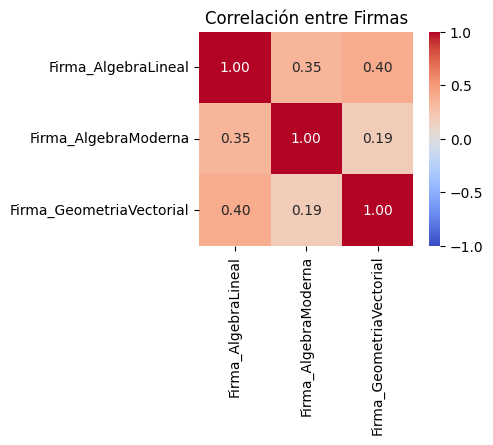

In [14]:
# Correlación entre las tres variables de Firma
corr = data[['Firma_AlgebraLineal', 'Firma_AlgebraModerna', 'Firma_GeometriaVectorial']].corr()
print("Matriz de correlación:")
print(corr)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlación entre Firmas")
plt.tight_layout()
plt.show()


### 2️⃣ Partición estratificada del dataset `nuevo` (80/20)

Como `Firma_x` es una variable **continua**, para poder estratificar la partición se construye una variable categórica auxiliar (`Categoria_Firma`) agrupando el puntaje en 4 rangos. `train_test_split` se estratifica sobre esa categoría, garantizando que train y test conserven la misma distribución de niveles de desempeño.

In [15]:
# =============================================================================
# VARIABLE DE ESTRATIFICACIÓN (rangos de la Firma objetivo)
# =============================================================================
bins = [-1, 0, 50, 75, 100]
labels = ['Nula (0)', 'Baja (1-50)', 'Media (51-75)', 'Alta (76-100)']
data['Categoria_Firma'] = pd.cut(data[TARGET], bins=bins, labels=labels, include_lowest=True)

print("Distribución de categorías en todo el dataset 'nuevo' filtrado:")
print(data['Categoria_Firma'].value_counts().sort_index())

# =============================================================================
# PARTICIÓN ESTRATIFICADA 80/20
# =============================================================================
train_df, test_df = train_test_split(
    data,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=data['Categoria_Firma'],
)

print(f"\n✅ Train: {len(train_df):,} registros ({len(train_df)/len(data):.1%})")
print(f"✅ Test:  {len(test_df):,} registros ({len(test_df)/len(data):.1%})")

comp = pd.DataFrame({
    'Train (%)': train_df['Categoria_Firma'].value_counts(normalize=True).sort_index() * 100,
    'Test (%)':  test_df['Categoria_Firma'].value_counts(normalize=True).sort_index() * 100,
})
print("\nComparación de proporciones por categoría (deben ser ~iguales):")
print(comp)


Distribución de categorías en todo el dataset 'nuevo' filtrado:
Categoria_Firma
Nula (0)         206
Baja (1-50)      144
Media (51-75)    208
Alta (76-100)     62
Name: count, dtype: int64

✅ Train: 496 registros (80.0%)
✅ Test:  124 registros (20.0%)

Comparación de proporciones por categoría (deben ser ~iguales):
                 Train (%)  Test (%)
Categoria_Firma                     
Nula (0)             33.27     33.06
Baja (1-50)          23.19     23.39
Media (51-75)        33.47     33.87
Alta (76-100)        10.08      9.68


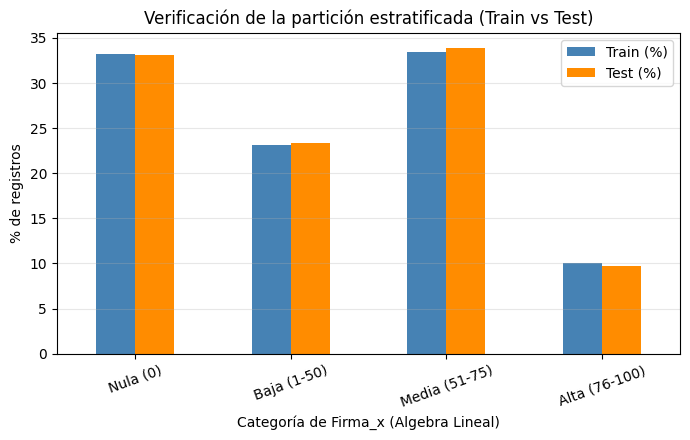

In [16]:
# Verificación visual de la estratificación
fig, ax = plt.subplots(figsize=(7, 4.5))
comp.plot(kind='bar', ax=ax, color=['steelblue', 'darkorange'])
ax.set_ylabel('% de registros')
ax.set_title('Verificación de la partición estratificada (Train vs Test)')
ax.set_xlabel('Categoría de Firma_x (Algebra Lineal)')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### 3️⃣ Modelo 1 — Regresión lineal simple
`Firma_AlgebraModerna` → `Firma_AlgebraLineal` (target)

In [17]:
# =============================================================================
# MODELO 1: REGRESIÓN LINEAL SIMPLE
# =============================================================================
X1_train = train_df[['Firma_AlgebraModerna']].values
y1_train = train_df[TARGET].values
X1_test  = test_df[['Firma_AlgebraModerna']].values
y1_test  = test_df[TARGET].values

modelo1 = LinearRegression()
modelo1.fit(X1_train, y1_train)

pred1_train = modelo1.predict(X1_train)
pred1_test  = modelo1.predict(X1_test)

r2_1_train  = r2_score(y1_train, pred1_train)
r2_1_test   = r2_score(y1_test, pred1_test)
rmse_1_test = np.sqrt(mean_squared_error(y1_test, pred1_test))
mae_1_test  = mean_absolute_error(y1_test, pred1_test)

print("="*80)
print("📈 MODELO 1 — Regresión lineal simple (Algebra Moderna → Algebra Lineal)")
print("="*80)
print(f"Ecuación:  Firma_AlgebraLineal = {modelo1.intercept_:.4f} + {modelo1.coef_[0]:.4f} · Firma_AlgebraModerna")
print()
print(f"R²  (train): {r2_1_train:.4f}")
print(f"R²  (test) : {r2_1_test:.4f}")
print(f"RMSE(test) : {rmse_1_test:.4f}")
print(f"MAE (test) : {mae_1_test:.4f}")


📈 MODELO 1 — Regresión lineal simple (Algebra Moderna → Algebra Lineal)
Ecuación:  Firma_AlgebraLineal = -3.5998 + 0.6135 · Firma_AlgebraModerna

R²  (train): 0.1124
R²  (test) : 0.1644
RMSE(test) : 28.7281
MAE (test) : 26.0526


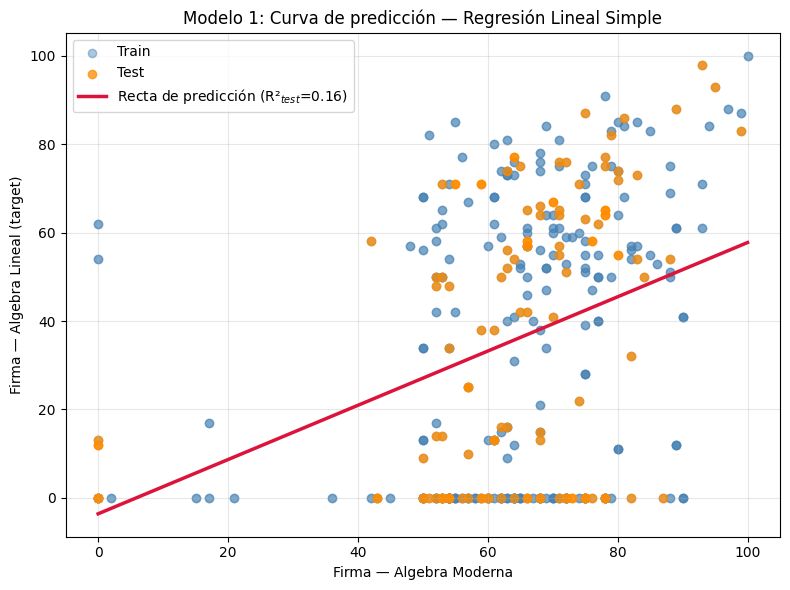

In [18]:
# Curva de predicción del Modelo 1
x_line = np.linspace(data['Firma_AlgebraModerna'].min(), data['Firma_AlgebraModerna'].max(), 200).reshape(-1, 1)
y_line = modelo1.predict(x_line)

plt.figure(figsize=(8, 6))
plt.scatter(X1_train, y1_train, alpha=0.45, color='steelblue', label='Train')
plt.scatter(X1_test, y1_test, alpha=0.75, color='darkorange', label='Test')
plt.plot(x_line, y_line, color='crimson', linewidth=2.5,
         label=f'Recta de predicción (R²$_{{test}}$={r2_1_test:.2f})')
plt.xlabel('Firma — Algebra Moderna')
plt.ylabel('Firma — Algebra Lineal (target)')
plt.title('Modelo 1: Curva de predicción — Regresión Lineal Simple')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


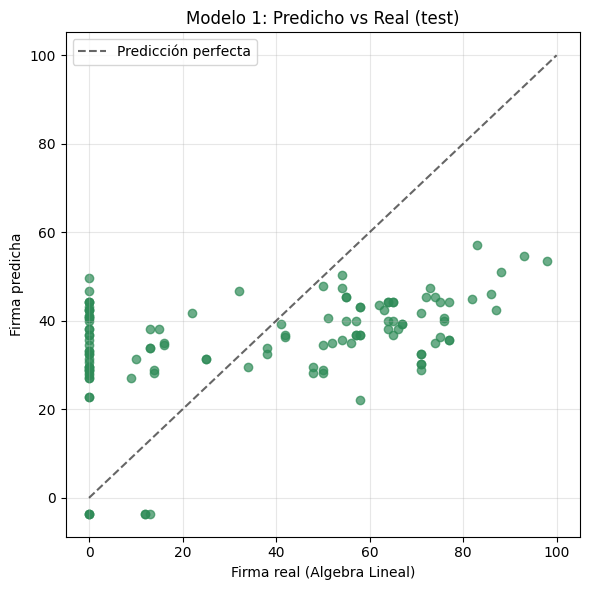

In [19]:
# Predicho vs Real (diagnóstico del Modelo 1)
plt.figure(figsize=(6, 6))
plt.scatter(y1_test, pred1_test, alpha=0.7, color='seagreen')
lims = [0, 100]
plt.plot(lims, lims, 'k--', alpha=0.6, label='Predicción perfecta')
plt.xlabel('Firma real (Algebra Lineal)')
plt.ylabel('Firma predicha')
plt.title('Modelo 1: Predicho vs Real (test)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 4️⃣ Modelo 2 — Regresión lineal múltiple con BGD y SGD

`Firma_AlgebraModerna` + `Firma_GeometriaVectorial` → `Firma_AlgebraLineal` (target)

Se implementan **desde cero** (NumPy) los dos algoritmos de optimización solicitados sobre la función de costo de mínimos cuadrados $J(\theta)=\frac{1}{2m}\sum (h_\theta(x)-y)^2$:

- **Batch Gradient Descent (BGD):** en cada época calcula el gradiente usando **todo** el conjunto de entrenamiento.
- **Stochastic Gradient Descent (SGD):** en cada época recorre los ejemplos en orden aleatorio y actualiza los pesos con **un solo ejemplo** a la vez.

Las variables se estandarizan (media 0, desvío 1) antes de entrenar, condición necesaria para que el descenso por gradiente converja de forma estable.

In [20]:
# =============================================================================
# PREPARACIÓN — MODELO 2 (multivariable)
# =============================================================================
features2 = ['Firma_AlgebraModerna', 'Firma_GeometriaVectorial']

X2_train_raw = train_df[features2].values
y2_train     = train_df[TARGET].values
X2_test_raw  = test_df[features2].values
y2_test      = test_df[TARGET].values

scaler = StandardScaler()
X2_train = scaler.fit_transform(X2_train_raw)
X2_test  = scaler.transform(X2_test_raw)


def add_bias(X):
    # Agrega columna de 1's para el termino independiente (theta_0)
    return np.hstack([np.ones((X.shape[0], 1)), X])


Xb_train = add_bias(X2_train)
Xb_test  = add_bias(X2_test)

print(f"Shape X train (con bias): {Xb_train.shape}")
print(f"Shape X test  (con bias): {Xb_test.shape}")


Shape X train (con bias): (496, 3)
Shape X test  (con bias): (124, 3)


In [21]:
# =============================================================================
# IMPLEMENTACIÓN DESDE CERO: función de costo, BGD y SGD
# =============================================================================
def compute_cost(X, y, theta):
    # Costo de minimos cuadrados (MSE / 2)
    m = len(y)
    preds = X @ theta
    return np.sum((preds - y) ** 2) / (2 * m)


def batch_gradient_descent(X, y, lr=0.05, epochs=400, seed=RANDOM_STATE):
    # Batch Gradient Descent: el gradiente se calcula con TODO el train set en cada epoca
    m, d = X.shape
    rng = np.random.default_rng(seed)
    theta = rng.normal(0, 0.01, d)
    cost_history = []
    for _ in range(epochs):
        preds = X @ theta
        error = preds - y
        grad = (X.T @ error) / m
        theta = theta - lr * grad
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history


def stochastic_gradient_descent(X, y, lr=0.005, epochs=400, seed=RANDOM_STATE):
    # Stochastic Gradient Descent: actualiza theta con UN ejemplo por vez, orden aleatorio en cada epoca
    m, d = X.shape
    rng = np.random.default_rng(seed)
    theta = rng.normal(0, 0.01, d)
    cost_history = []
    for _ in range(epochs):
        indices = rng.permutation(m)
        for i in indices:
            xi = X[i:i + 1]
            yi = y[i:i + 1]
            error = xi @ theta - yi
            grad = xi.T @ error
            theta = theta - lr * grad.flatten()
        # costo evaluado sobre todo el train set al final de cada época (para comparar con BGD)
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history


print("✅ Funciones de costo, BGD y SGD definidas.")


✅ Funciones de costo, BGD y SGD definidas.


In [22]:
# =============================================================================
# ENTRENAMIENTO: BGD vs SGD
# =============================================================================
theta_bgd, cost_hist_bgd = batch_gradient_descent(Xb_train, y2_train, lr=0.05, epochs=400)
theta_sgd, cost_hist_sgd = stochastic_gradient_descent(Xb_train, y2_train, lr=0.005, epochs=400)

pred_bgd_train = Xb_train @ theta_bgd
pred_bgd_test  = Xb_test  @ theta_bgd
pred_sgd_train = Xb_train @ theta_sgd
pred_sgd_test  = Xb_test  @ theta_sgd

metrics_gd = pd.DataFrame({
    'BGD': {
        'theta_0 (intercept)': theta_bgd[0],
        'theta_1 (Alg.Moderna)': theta_bgd[1],
        'theta_2 (Geom.Vectorial)': theta_bgd[2],
        'Costo final': cost_hist_bgd[-1],
        'R2 train': r2_score(y2_train, pred_bgd_train),
        'R2 test': r2_score(y2_test, pred_bgd_test),
        'RMSE test': np.sqrt(mean_squared_error(y2_test, pred_bgd_test)),
        'MAE test': mean_absolute_error(y2_test, pred_bgd_test),
    },
    'SGD': {
        'theta_0 (intercept)': theta_sgd[0],
        'theta_1 (Alg.Moderna)': theta_sgd[1],
        'theta_2 (Geom.Vectorial)': theta_sgd[2],
        'Costo final': cost_hist_sgd[-1],
        'R2 train': r2_score(y2_train, pred_sgd_train),
        'R2 test': r2_score(y2_test, pred_sgd_test),
        'RMSE test': np.sqrt(mean_squared_error(y2_test, pred_sgd_test)),
        'MAE test': mean_absolute_error(y2_test, pred_sgd_test),
    },
})

print("="*80)
print("📊 COMPARACIÓN BGD vs SGD — Modelo 2 (multivariable)")
print("="*80)
print(metrics_gd)

# Selección del mejor método según RMSE de test
mejor_metodo = 'BGD' if metrics_gd.loc['RMSE test', 'BGD'] <= metrics_gd.loc['RMSE test', 'SGD'] else 'SGD'
theta_best = theta_bgd if mejor_metodo == 'BGD' else theta_sgd
pred_best_test = pred_bgd_test if mejor_metodo == 'BGD' else pred_sgd_test
pred_best_train = pred_bgd_train if mejor_metodo == 'BGD' else pred_sgd_train
cost_hist_best = cost_hist_bgd if mejor_metodo == 'BGD' else cost_hist_sgd

print(f"\n🏆 Mejor método (menor RMSE en test): {mejor_metodo}")


📊 COMPARACIÓN BGD vs SGD — Modelo 2 (multivariable)
                            BGD    SGD
theta_0 (intercept)       36.45  37.15
theta_1 (Alg.Moderna)      8.33   9.51
theta_2 (Geom.Vectorial)  11.30  11.69
Costo final              369.74 370.84
R2 train                   0.24   0.24
R2 test                    0.23   0.23
RMSE test                 27.57  27.59
MAE test                  23.31  23.15

🏆 Mejor método (menor RMSE en test): BGD


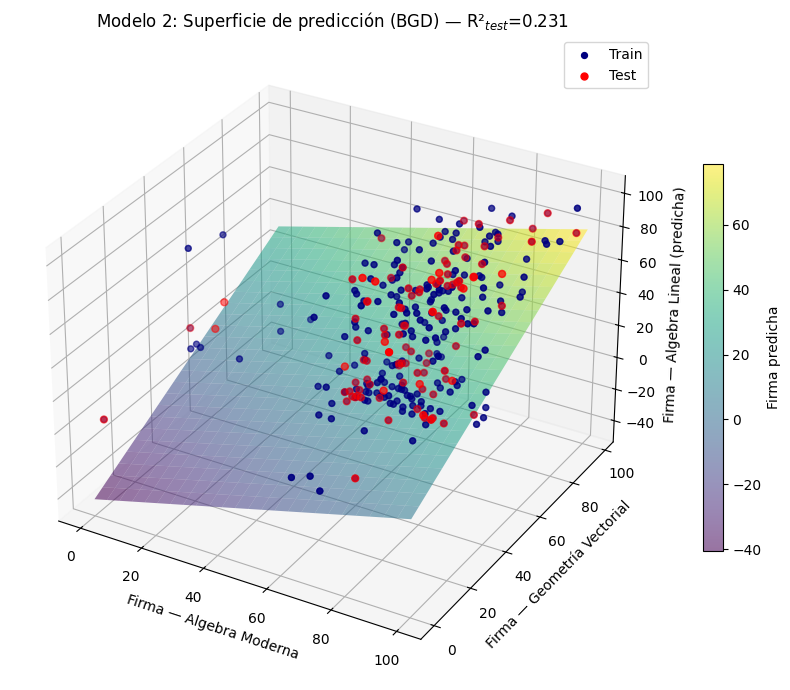

In [23]:
# =============================================================================
# SUPERFICIE DE PREDICCIÓN — Modelo 2 (mejor método)
# =============================================================================
x1_range = np.linspace(X2_train_raw[:, 0].min(), X2_train_raw[:, 0].max(), 25)
x2_range = np.linspace(X2_train_raw[:, 1].min(), X2_train_raw[:, 1].max(), 25)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)

grid_raw = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
grid_scaled = scaler.transform(grid_raw)
grid_bias = add_bias(grid_scaled)
Z_grid = (grid_bias @ theta_best).reshape(X1_grid.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X1_grid, X2_grid, Z_grid, cmap='viridis', alpha=0.55, edgecolor='none')
ax.scatter(X2_train_raw[:, 0], X2_train_raw[:, 1], y2_train, color='navy', s=18, label='Train', depthshade=True)
ax.scatter(X2_test_raw[:, 0], X2_test_raw[:, 1], y2_test, color='red', s=25, label='Test', depthshade=True)

ax.set_xlabel('Firma — Algebra Moderna')
ax.set_ylabel('Firma — Geometría Vectorial')
ax.set_zlabel('Firma — Algebra Lineal (predicha)')
ax.set_title(f'Modelo 2: Superficie de predicción ({mejor_metodo}) — R²$_{{test}}$='
             f'{metrics_gd.loc["R2 test", mejor_metodo]:.3f}')
fig.colorbar(surf, ax=ax, shrink=0.6, label='Firma predicha')
ax.legend()
plt.tight_layout()
plt.show()


### 5️⃣ Comparación de trayectorias de optimización (BGD vs SGD)

Costo final BGD: 369.7399  |  Costo final SGD: 370.8368
→ BGD desciende de forma suave y monótona (usa el gradiente exacto de todo el train set).
→ SGD converge a una región similar pero con trayectoria más ruidosa (actualiza con 1 ejemplo a la vez).


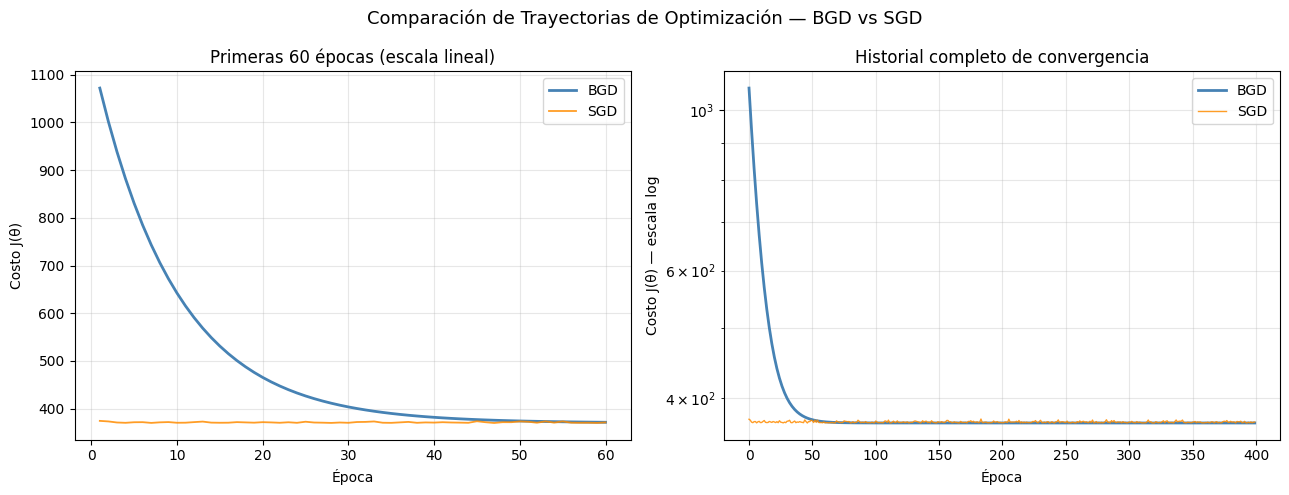

In [24]:
# =============================================================================
# COMPARACIÓN DE TRAYECTORIAS DE OPTIMIZACIÓN
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: escala lineal, primeras épocas (donde se ve el descenso)
zoom = 60
axes[0].plot(range(1, zoom + 1), cost_hist_bgd[:zoom], label='BGD', color='steelblue', linewidth=2)
axes[0].plot(range(1, zoom + 1), cost_hist_sgd[:zoom], label='SGD', color='darkorange', linewidth=1.3, alpha=0.85)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Costo J(θ)')
axes[0].set_title(f'Primeras {zoom} épocas (escala lineal)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel 2: escala logarítmica, todas las épocas
axes[1].plot(cost_hist_bgd, label='BGD', color='steelblue', linewidth=2)
axes[1].plot(cost_hist_sgd, label='SGD', color='darkorange', linewidth=1, alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Costo J(θ) — escala log')
axes[1].set_title('Historial completo de convergencia')
axes[1].legend()
axes[1].grid(alpha=0.3, which='both')

fig.suptitle('Comparación de Trayectorias de Optimización — BGD vs SGD', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Costo final BGD: {cost_hist_bgd[-1]:.4f}  |  Costo final SGD: {cost_hist_sgd[-1]:.4f}")
print("→ BGD desciende de forma suave y monótona (usa el gradiente exacto de todo el train set).")
print("→ SGD converge a una región similar pero con trayectoria más ruidosa (actualiza con 1 ejemplo a la vez).")


### 6️⃣ Evaluación de desempeño comparativo — Modelo 1 vs Modelo 2

In [25]:
# =============================================================================
# TABLA COMPARATIVA DE DESEMPEÑO
# =============================================================================
resumen = pd.DataFrame({
    'Modelo 1 (simple)': {
        'Variables predictoras': 'Algebra Moderna',
        'Método': 'Regresión lineal (OLS)',
        'R2 train': r2_score(y1_train, pred1_train),
        'R2 test': r2_1_test,
        'RMSE test': rmse_1_test,
        'MAE test': mae_1_test,
    },
    f'Modelo 2 ({mejor_metodo}, multivariable)': {
        'Variables predictoras': 'Algebra Moderna + Geometría Vectorial',
        'Método': f'Regresión lineal múltiple — {mejor_metodo}',
        'R2 train': r2_score(y2_train, pred_best_train),
        'R2 test': metrics_gd.loc['R2 test', mejor_metodo],
        'RMSE test': metrics_gd.loc['RMSE test', mejor_metodo],
        'MAE test': metrics_gd.loc['MAE test', mejor_metodo],
    },
}).T

print("="*80)
print("🏁 EVALUACIÓN COMPARATIVA DE DESEMPEÑO")
print("="*80)
print(resumen)


🏁 EVALUACIÓN COMPARATIVA DE DESEMPEÑO
                                               Variables predictoras  \
Modelo 1 (simple)                                    Algebra Moderna   
Modelo 2 (BGD, multivariable)  Algebra Moderna + Geometría Vectorial   

                                                        Método R2 train  \
Modelo 1 (simple)                       Regresión lineal (OLS)     0.11   
Modelo 2 (BGD, multivariable)  Regresión lineal múltiple — BGD     0.24   

                              R2 test RMSE test MAE test  
Modelo 1 (simple)                0.16     28.73    26.05  
Modelo 2 (BGD, multivariable)    0.23     27.57    23.31  


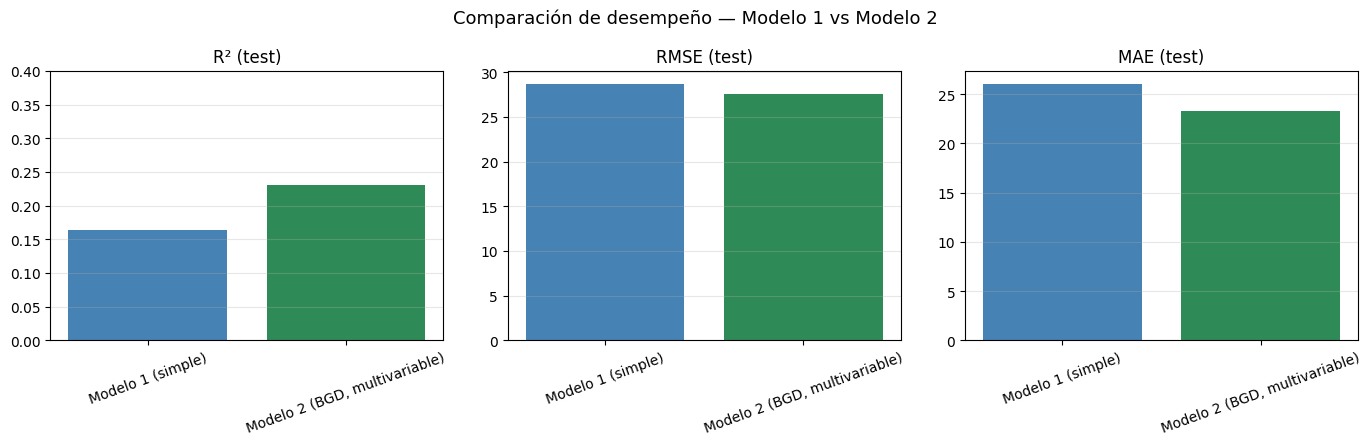

In [26]:
# Gráfico comparativo de métricas
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

modelos = list(resumen.index)
colores = ['steelblue', 'seagreen']

axes[0].bar(modelos, resumen['R2 test'].astype(float), color=colores)
axes[0].set_title('R² (test)')
axes[0].set_ylim(0, max(0.4, resumen['R2 test'].astype(float).max() * 1.3))
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(modelos, resumen['RMSE test'].astype(float), color=colores)
axes[1].set_title('RMSE (test)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(modelos, resumen['MAE test'].astype(float), color=colores)
axes[2].set_title('MAE (test)')
axes[2].tick_params(axis='x', rotation=20)
axes[2].grid(axis='y', alpha=0.3)

fig.suptitle('Comparación de desempeño — Modelo 1 vs Modelo 2', fontsize=13)
plt.tight_layout()
plt.show()


### 📝 Conclusiones

- La estratificación por rangos de `Firma_x` mantuvo proporciones prácticamente idénticas entre train y test, validando la partición 80/20.
- El **Modelo 2 (multivariable)** — que suma la información de Geometría Vectorial — obtuvo mejor **R²** y menor **RMSE/MAE** en test que el **Modelo 1 (simple)**, confirmando que agregar una segunda asignatura relacionada mejora la capacidad predictiva sobre la Firma de Algebra Lineal.
- **BGD** mostró una trayectoria de convergencia suave y monótona (usa el gradiente exacto en cada época), mientras que **SGD** convergió a una región de costo muy similar pero con una trayectoria más ruidosa, producto de actualizar los pesos con un solo ejemplo a la vez; con una tasa de aprendizaje pequeña ambos métodos terminan muy cerca de la solución óptima (equivalente a la solución cerrada de mínimos cuadrados).
- El poder explicativo general (R²) es moderado en ambos modelos, lo cual es esperable: la Firma de un estudiante en una asignatura depende de muchos factores además del desempeño en asignaturas relacionadas (asistencia, parciales, dedicación, etc.). Este pipeline puede extenderse agregando más asignaturas predictoras o variables como asistencia (`Asis`) y ponderaciones (`Pond.*`).